# Speech Emotion Detection (RAVDESS) - Hexovate Task 3
Steps: 1) load + explore, 2) MFCC features, 3) actor-based split, 4) train with class weights, 5) evaluate, 6) save model, 7) optional CNN.
Run on Google Colab or Kaggle (free).

In [2]:
!pip -q install librosa soundfile scikit-learn matplotlib seaborn pandas joblib kagglehub

## 1. Download and load the data

In [3]:
# --- Option A (Colab): needs a Kaggle API key (kaggle.json) uploaded, or use Option B
import kagglehub
DATA_DIR = kagglehub.dataset_download("uwrfkaggler/ravdess-emotional-speech-audio")
# --- Option B (Kaggle notebook): add the dataset in the sidebar, then use:
# DATA_DIR = "/kaggle/input/ravdess-emotional-speech-audio"
print(DATA_DIR)

100%|██████████| 429M/429M [00:04<00:00, 110MB/s] 

Extracting files...


/root/.cache/kagglehub/datasets/uwrfkaggler/ravdess-emotional-speech-audio/versions/1


In [4]:
import os, glob, json
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import librosa, librosa.display

# file name = modality-channel-emotion-intensity-statement-repetition-actor.wav
EMOTIONS = {"01": "neutral", "03": "happy", "04": "sad", "05": "angry"}
LABELS = ["angry", "happy", "sad", "neutral"]

rows, seen = [], set()
for p in glob.glob(os.path.join(DATA_DIR, "**", "*.wav"), recursive=True):
    name = os.path.basename(p)
    parts = name.replace(".wav", "").split("-")
    if len(parts) != 7 or name in seen:
        continue
    modality, channel, emo, inten, stmt, rep, actor = parts
    if channel != "01" or emo not in EMOTIONS:   # speech only, 4 emotions only
        continue
    seen.add(name)
    rows.append(dict(path=p, emotion=EMOTIONS[emo], actor=int(actor)))

df = pd.DataFrame(rows).sort_values(["actor", "path"]).reset_index(drop=True)
print("Total clips:", len(df))      # expected 672
print(df.emotion.value_counts())    # 192 / 192 / 192 / 96

Total clips: 672
emotion
happy      192
sad        192
angry      192
neutral     96
Name: count, dtype: int64


## 2. Explore: class counts, waveform and mel spectrogram per emotion

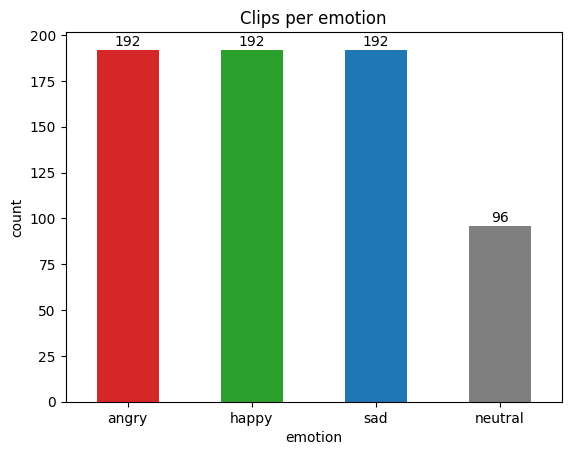

In [5]:
counts = df.emotion.value_counts().reindex(LABELS)
ax = counts.plot(kind="bar", color=["#d62728","#2ca02c","#1f77b4","#7f7f7f"], rot=0)
ax.set_title("Clips per emotion"); ax.set_ylabel("count")
for i, v in enumerate(counts): ax.text(i, v + 2, str(v), ha="center")
plt.show()

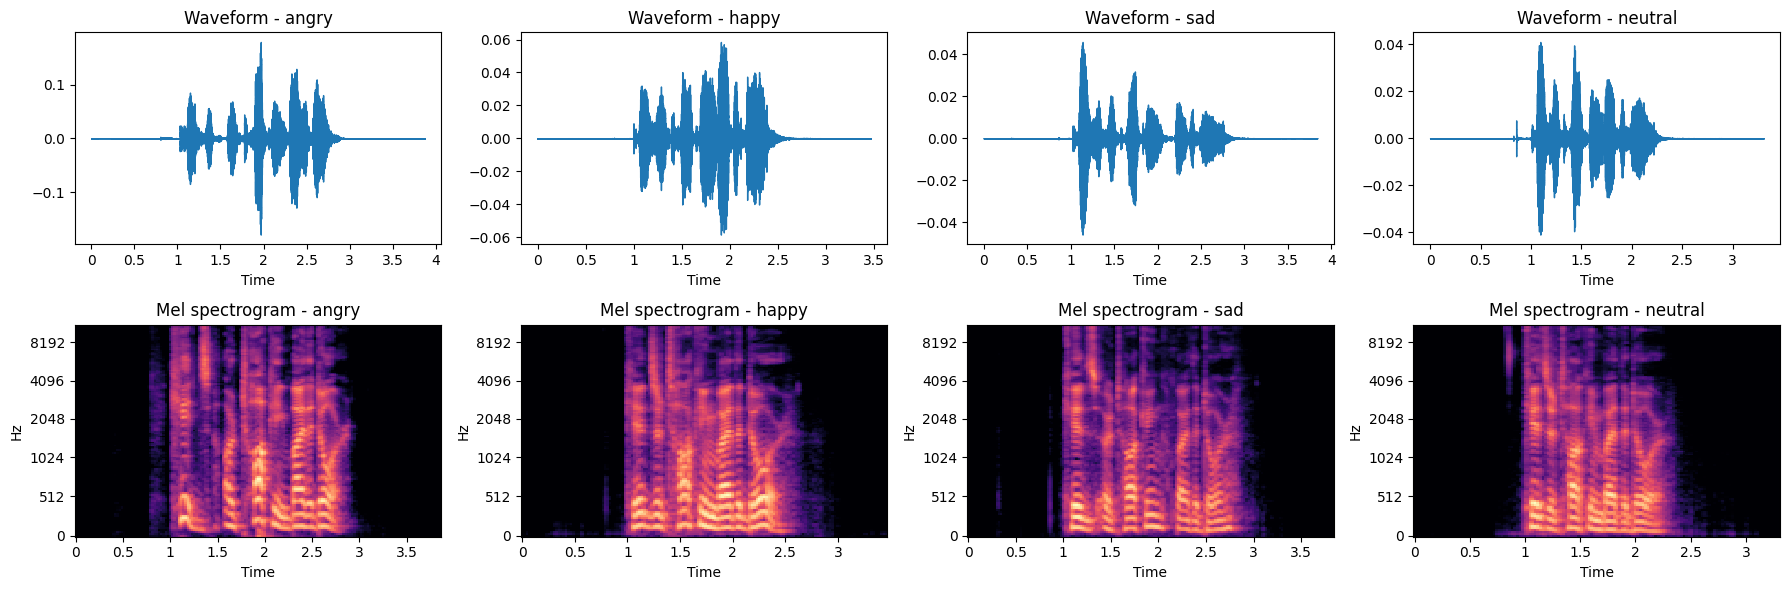

In [6]:
SR = 22050
fig, axes = plt.subplots(2, 4, figsize=(18, 6))
for i, emo in enumerate(LABELS):
    path = df[df.emotion == emo].iloc[0].path
    y, _ = librosa.load(path, sr=SR)
    librosa.display.waveshow(y, sr=SR, ax=axes[0, i]); axes[0, i].set_title(f"Waveform - {emo}")
    S = librosa.power_to_db(librosa.feature.melspectrogram(y=y, sr=SR, n_mels=128), ref=np.max)
    librosa.display.specshow(S, sr=SR, x_axis="time", y_axis="mel", ax=axes[1, i]); axes[1, i].set_title(f"Mel spectrogram - {emo}")
plt.tight_layout(); plt.show()

## 3. Extract MFCC features (mean + std of 40 MFCCs = 80 features per clip)

In [7]:
def load_audio(path, sr=SR):
    y, _ = librosa.load(path, sr=sr, duration=4.0)
    y, _ = librosa.effects.trim(y, top_db=25)   # remove leading/trailing silence
    return y

def extract_features(y, sr=SR):
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
    return np.concatenate([mfcc.mean(axis=1), mfcc.std(axis=1)])

X = np.array([extract_features(load_audio(p)) for p in df.path])
feat_cols = [f"mfcc{i}_mean" for i in range(40)] + [f"mfcc{i}_std" for i in range(40)]
feat_df = pd.DataFrame(X, columns=feat_cols)
feat_df["emotion"], feat_df["actor"] = df.emotion.values, df.actor.values
feat_df.to_csv("features.csv", index=False)
feat_df.head()

,mfcc0_mean,mfcc1_mean,mfcc2_mean,mfcc3_mean,mfcc4_mean,mfcc5_mean,mfcc6_mean,mfcc7_mean,mfcc8_mean,mfcc9_mean,...,mfcc32_std,mfcc33_std,mfcc34_std,mfcc35_std,mfcc36_std,mfcc37_std,mfcc38_std,mfcc39_std,emotion,actor
0,-481.905609,125.548500,-9.639902,25.167789,14.366634,-5.141540,-9.502490,-12.414044,-28.671183,-10.056912,...,4.981232,5.224855,3.505803,4.612251,3.599945,4.756579,4.173026,3.365785,neutral,1
1,-478.835419,118.245613,-6.950248,28.989891,14.234001,-7.033341,-8.363734,-14.183152,-28.839911,-6.583601,...,3.916974,5.613610,4.745111,4.280282,3.387979,3.937891,2.880066,4.782963,neutral,1
2,-467.461426,123.837830,-5.577744,28.067640,5.481349,-2.434216,-8.276038,-15.330316,-26.384604,-10.839216,...,4.266776,5.544558,3.952373,3.957696,3.921083,4.442653,3.555942,4.286138,neutral,1
3,-467.978638,114.493721,0.546527,28.502628,9.155950,0.441281,-8.208540,-17.950306,-24.476181,-9.278924,...,6.422099,5.591656,3.740158,4.405076,3.594911,3.586221,3.953243,4.278378,neutral,1
4,-439.796783,124.682472,-12.899962,24.320784,4.877738,-8.717663,-13.365322,-13.016000,-25.592541,-7.975532,...,4.092723,5.738970,6.429771,4.425123,3.821666,7.081125,8.864164,7.288754,happy,1


## 4. Split by actor (train: actors 1-18, test: actors 19-24)
The model is tested on voices it has never heard.

In [8]:
train_mask = df.actor <= 18
X_train, y_train, g_train = X[train_mask], df.emotion[train_mask].values, df.actor[train_mask].values
X_test,  y_test           = X[~train_mask], df.emotion[~train_mask].values
print("Train clips:", len(X_train), pd.Series(y_train).value_counts().to_dict())
print("Test clips :", len(X_test),  pd.Series(y_test).value_counts().to_dict())
assert set(df.actor[train_mask]).isdisjoint(set(df.actor[~train_mask]))

Train clips: 504 {'happy': 144, 'sad': 144, 'angry': 144, 'neutral': 72}
Test clips : 168 {'happy': 48, 'sad': 48, 'angry': 48, 'neutral': 24}


## 5. Train with class weights (neutral is smaller) and compare SVM vs Random Forest
Model choice uses GroupKFold on the TRAIN actors only, so the test actors stay untouched.

In [9]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold, cross_val_score

models = {
    "SVM": Pipeline([("scaler", StandardScaler()),
                     ("clf", SVC(kernel="rbf", C=10, gamma="scale", class_weight="balanced",
                                 probability=True, random_state=42))]),
    "RandomForest": RandomForestClassifier(n_estimators=300, class_weight="balanced",
                                           random_state=42, n_jobs=-1),
}
cv_scores = {}
for name, m in models.items():
    s = cross_val_score(m, X_train, y_train, groups=g_train, cv=GroupKFold(5), scoring="f1_macro")
    cv_scores[name] = s.mean(); print(f"{name}: CV macro F1 = {s.mean():.3f} (+/- {s.std():.3f})")

best_name = max(cv_scores, key=cv_scores.get)
print("Chosen model:", best_name)
model = models[best_name].fit(X_train, y_train)

SVM: CV macro F1 = 0.476 (+/- 0.084)
RandomForest: CV macro F1 = 0.494 (+/- 0.062)
Chosen model: RandomForest


## 6. Evaluate on unseen actors

Accuracy: 0.667 | Macro F1: 0.614

              precision    recall  f1-score   support

       angry      0.812     0.812     0.812        48
       happy      0.667     0.625     0.645        48
         sad      0.587     0.771     0.667        48
     neutral      0.500     0.250     0.333        24

    accuracy                          0.667       168
   macro avg      0.642     0.615     0.614       168
weighted avg      0.662     0.667     0.655       168



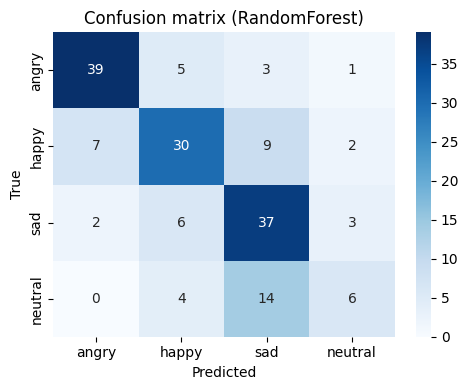

In [10]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
pred = model.predict(X_test)
acc, mf1 = accuracy_score(y_test, pred), f1_score(y_test, pred, average="macro")
print(f"Accuracy: {acc:.3f} | Macro F1: {mf1:.3f}\n")
print(classification_report(y_test, pred, labels=LABELS, digits=3))

cm = confusion_matrix(y_test, pred, labels=LABELS)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=LABELS, yticklabels=LABELS)
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title(f"Confusion matrix ({best_name})")
plt.tight_layout(); plt.savefig("confusion_matrix.png", dpi=150); plt.show()

### Confusion analysis (write YOUR 3-4 sentences here after seeing your own matrix)
Look at the off-diagonal cells: which emotions are mixed up most? Typical results on RAVDESS: *angry* and *happy* are confused
because both are high-energy and loud; *sad* and *neutral* are confused because both are quiet and low-pitched.
Neutral is the weakest class because it has half as many training clips.

## 7. Save model, metrics and class counts (the dashboard reads these files)

In [12]:
import joblib
joblib.dump({"model": model, "labels": list(model.classes_)}, "model.joblib")
metrics = {
    "model": best_name, "accuracy": acc, "macro_f1": mf1, "labels": LABELS,
    "confusion_matrix": cm.tolist(),
    "class_counts": df.emotion.value_counts().reindex(LABELS).to_dict(),
    "train_actors": "1-18", "test_actors": "19-24",
    "n_train": int(len(X_train)), "n_test": int(len(X_test)),
    "cv_macro_f1": cv_scores,
    "report": classification_report(y_test, pred, labels=LABELS, output_dict=True),
}
json.dump(metrics, open("metrics.json", "w"), indent=2)
print("Saved model.joblib, metrics.json, confusion_matrix.png, features.csv")

Saved model.joblib, metrics.json, confusion_matrix.png, features.csv


## 8. (Optional) Small CNN on mel spectrograms

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models as km
from sklearn.utils.class_weight import compute_class_weight

N_FRAMES = 173   # ~4 s at 22,050 Hz with hop 512
def mel_img(path):
    y = load_audio(path)
    S = librosa.power_to_db(librosa.feature.melspectrogram(y=y, sr=SR, n_mels=128), ref=np.max)
    S = S[:, :N_FRAMES]
    S = np.pad(S, ((0, 0), (0, N_FRAMES - S.shape[1])), constant_values=S.min())
    return (S + 40) / 40   # rough scaling

M = np.array([mel_img(p) for p in df.path])[..., None]
lab2id = {l: i for i, l in enumerate(LABELS)}
y_all = df.emotion.map(lab2id).values
tr = (df.actor <= 14).values; va = ((df.actor > 14) & (df.actor <= 18)).values; te = (df.actor > 18).values

cnn = km.Sequential([
    layers.Input((128, N_FRAMES, 1)),
    layers.Conv2D(16, 3, activation="relu"), layers.MaxPooling2D(2),
    layers.Conv2D(32, 3, activation="relu"), layers.MaxPooling2D(2),
    layers.Conv2D(64, 3, activation="relu"), layers.GlobalAveragePooling2D(),
    layers.Dropout(0.4), layers.Dense(4, activation="softmax")])
cnn.compile("adam", "sparse_categorical_crossentropy", metrics=["accuracy"])
cw = dict(enumerate(compute_class_weight("balanced", classes=np.arange(4), y=y_all[tr])))
cnn.fit(M[tr], y_all[tr], validation_data=(M[va], y_all[va]), epochs=40, batch_size=16,
        class_weight=cw, callbacks=[tf.keras.callbacks.EarlyStopping(patience=8, restore_best_weights=True)])
p = cnn.predict(M[te]).argmax(1)
print(f"CNN  -> Accuracy {accuracy_score(y_all[te], p):.3f} | Macro F1 {f1_score(y_all[te], p, average='macro'):.3f}")
print(f"{best_name} -> Accuracy {acc:.3f} | Macro F1 {mf1:.3f}")

Compare the two results above in your report. With only 672 clips, the MFCC + SVM/RF model is often as good as or better than the CNN.